# Extract Feature from Each Frame

In [34]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

In [35]:
# extract features from the CSV file
def extract_frame_features(frame_df):
    num_objects = len(frame_df)
    avg_conf = frame_df["confidence"].mean()
    avg_box_area = ((frame_df["x_max"] - frame_df["x_min"]) *
                    (frame_df["y_max"] - frame_df["y_min"])).mean()

    desired_size = 13  # fixed number of object classes expected
    class_counts = np.zeros(desired_size)

    for cls in frame_df["object_class"]:
        cls = int(cls)
        if cls < desired_size:
            class_counts[cls] += 1  # only count classes within desired_size

    return torch.tensor([num_objects, avg_conf, avg_box_area] + class_counts.tolist(), dtype=torch.float32)

# Process the CSV file and extract features for each frame
def process_video_csv(csv_path):
    df = pd.read_csv(csv_path)

    sequences = []
    if "frame" not in df.columns or df.empty:
        return torch.empty(0, 16)  # return empty tensor with correct shape

    for _, frame_df in df.groupby("frame"):
        frame_feat = extract_frame_features(frame_df)
        sequences.append(frame_feat)

    if not sequences:
        return torch.empty(0, 16)  
    return torch.stack(sequences)




# Load Data Labels

In [36]:
import csv

# Load label CSV into a dictionary
label_dict = {}
with open("../data/train_labels.csv", newline = "") as f:
    reader = csv.DictReader(f)
    for row in reader:
        label_dict[row["id"]] = int(row["target"])

# Split Data into Training, Validation, and Test Sets

In [37]:
from sklearn.model_selection import train_test_split

# Get all video directories
video_dirs = sorted([
    os.path.join("../data/yolo_processed_data", d)
    for d in os.listdir("../data/yolo_processed_data")
    if os.path.isdir(os.path.join("../data/yolo_processed_data", d))
])

# Initialize an empty list to store video_ids
video_ids = []

# Extract video IDs from the directory names, removing video_ prefix
for video_dir in video_dirs:
    video_id = os.path.basename(video_dir).replace("video_", "")
    video_ids.append(video_id)

# Ensure there are labels for all video IDs
for video_id in video_ids:
    if video_id not in label_dict:
        raise AssertionError(f"Label missing for video: {video_id}")



# Split the video IDs
train_ids, temp_ids = train_test_split(video_ids, test_size = 0.2)
val_ids, test_ids = train_test_split(temp_ids, test_size = 0.5)


# Initialize empty lists to store the video directories
train_videos = []
val_videos = []
test_videos = []

# Populate the train_videos list with the corresponding directories
for video_id in train_ids:
    video_dir = os.path.join("../data/yolo_processed_data", "video_" + video_id)
    train_videos.append(video_dir)

# Populate the val_videos list with the corresponding directories
for video_id in val_ids:
    video_dir = os.path.join("../data/yolo_processed_data", "video_" + video_id)
    val_videos.append(video_dir)

# Populate the test_videos list with the corresponding directories
for video_id in test_ids:
    video_dir = os.path.join("../data/yolo_processed_data", "video_" + video_id)
    test_videos.append(video_dir)

In [38]:
# Shape Sanity Check
print(f"-----Dataset Sizes-----")
print(f"Train videos: {len(train_videos) / len(video_dirs)}")
print(f"Validation videos: {len(val_videos) / len(video_dirs)}")
print(f"Test videos: {len(test_videos) / len(video_dirs)}\n")


print(f"-----Dataset Values-----")
print(f"Train Videos: {train_videos[0:2]}")
print(f"Validation Videos: {val_videos[0:2]}")
print(f"Test Videos: {test_videos[0:2]}")

-----Dataset Sizes-----
Train videos: 0.8
Validation videos: 0.1
Test videos: 0.1

-----Dataset Values-----
Train Videos: ['../data/yolo_processed_data/video_00452', '../data/yolo_processed_data/video_00483']
Validation Videos: ['../data/yolo_processed_data/video_01285', '../data/yolo_processed_data/video_01313']
Test Videos: ['../data/yolo_processed_data/video_01460', '../data/yolo_processed_data/video_00266']


# Create Dataset and DataLoader

In [39]:
# Create a dataset class for the video sequences
class VideoDataset(Dataset):
    def __init__(self, video_dirs, label_dict):
        self.video_dirs = video_dirs
        self.label_dict = label_dict

    def __len__(self):
        return len(self.video_dirs)
    
    def __getitem__(self, idx):
        video_dir = self.video_dirs[idx]
        video_id = os.path.basename(video_dir)
        label = self.label_dict.get(video_id, 0)

        csv_path = os.path.join(video_dir, "detections.csv")
        seq = process_video_csv(csv_path)

        return seq, torch.tensor(label, dtype = torch.float32)
    
    
# Collate function to pad sequences and create batches
def collate_fn(batch):
    # Filter out samples with empty sequences
    batch = [(x, y) for x, y in batch if x.size(0) > 0]

    if len(batch) == 0:
        return None  # skip batch if empty

    batch.sort(key=lambda x: x[0].size(0), reverse=True)
    sequences, labels = zip(*batch)
    lengths = torch.tensor([seq.size(0) for seq in sequences])

    padded_seqs = pad_sequence(sequences, batch_first=True)
    labels = torch.stack(labels)

    return padded_seqs, lengths, labels



# Create datasets for training and validation
train_dataset = VideoDataset(train_videos, label_dict)
val_dataset = VideoDataset(val_videos, label_dict)
test_dataset = VideoDataset(test_videos, label_dict)

# Create DataLoader objects for training, validation, and testing
train_loader = DataLoader(train_dataset, batch_size = 4, shuffle = True, collate_fn = collate_fn)
val_loader = DataLoader(val_dataset, batch_size = 4, shuffle = False, collate_fn = collate_fn)
test_loader = DataLoader(test_dataset, batch_size = 4, shuffle = False, collate_fn = collate_fn)

# Define the GRU Model

In [40]:
# Define the LSTM model for classification
class GRUClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers = 1):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first = True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hn = self.gru(packed)  
        out = self.fc(hn[-1])     # Get last hidden state
        return self.sigmoid(out).squeeze()



# Training Loop

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = 16  # 3 summary features + 10 class counts
model = GRUClassifier(input_dim, hidden_dim = 64).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
best_val_loss = float('inf')
patience_counter = 0
patience = 10
train_losses, val_losses = [], []

# Training loop
for epoch in range(20):
    model.train()
    train_loss = 0
    for batch in train_loader:
        if batch is None:
            continue

        x_batch, lengths, y_batch = batch
        x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch, lengths)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        # Accumulate training loss for each batch
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader) # Calculate avg loss per batch
    train_losses.append(avg_train_loss) #Store avg loss per batch
    print(f"Epoch {epoch + 1}, Loss: {avg_train_loss:.4f}")


    # Compute validation loss
    model.eval()
    val_loss = 0
    with torch.no_grad(): 
        for batch in val_loader:
            if batch is None:
                continue

            x_batch, lengths, y_batch = batch
            x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)

            outputs = model(x_batch, lengths)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss) # Calculate avg val loss per batch

    # Update best validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_gru_model.pth') # Save model

    else:
        patience_counter += 1 # Increase patience when val loss doesn't improve
        if patience_counter >= patience:
            print("Early stopping triggered")
            break
        

Epoch 1, Loss: 0.0855
Epoch 2, Loss: 0.0041
Epoch 3, Loss: 0.0014
Epoch 4, Loss: 0.0005
Epoch 5, Loss: 0.0003
Epoch 6, Loss: 0.0002
Epoch 7, Loss: 0.0002
Epoch 8, Loss: 0.0001
Epoch 9, Loss: 0.0001
Epoch 10, Loss: 0.0001
Epoch 11, Loss: 0.0001
Epoch 12, Loss: 0.0000
Epoch 13, Loss: 0.0000
Epoch 14, Loss: 0.0000
Epoch 15, Loss: 0.0000
Epoch 16, Loss: 0.0000
Epoch 17, Loss: 0.0000
Epoch 18, Loss: 0.0000
Epoch 19, Loss: 0.0000
Epoch 20, Loss: 0.0000


<function matplotlib.pyplot.show(close=None, block=None)>

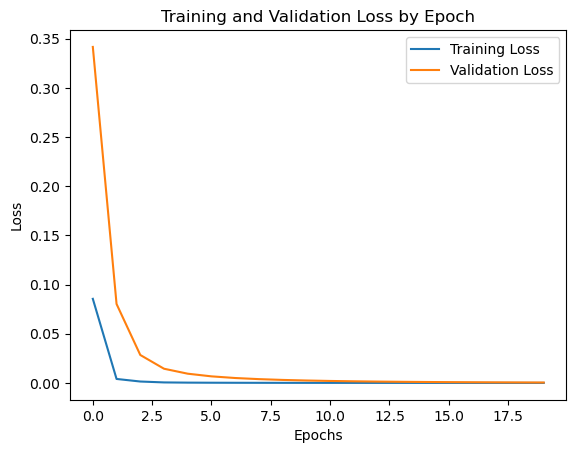

In [45]:
# Plot training and validation loss
plt.plot(train_losses, label = 'Training Loss')
plt.plot(val_losses, label = 'Validation Loss')
plt.title('Training and Validation Loss by Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show

In [47]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('best_gru_model.pth'))  # Load saved model parameters
model.eval()  # Set model to evaluation mode

# Initialize tracking variables
test_loss = 0
correct = 0
total = 0

with torch.no_grad():  # Disable gradient computation
    for batch in test_loader:
        if batch is None:
            continue
        x_batch, lengths, y_batch = batch
        x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)

        outputs = model(x_batch, lengths)  # Forward pass
        loss = criterion(outputs, y_batch)  # Binary cross entropy loss
        test_loss += loss.item()

        # Binary prediction threshold at 0.5
        predicted = (outputs > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

# Calculate test loss and accuracy
test_loss /= len(test_loader)
test_accuracy = correct / total

print('Final Results:')
print(f'Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')


/var/folders/sm/dt8s0j7j0glg1jfrlpndm0lw0000gn/T/ipykernel_6960/4050270607.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_gru_mod

Final Results:
Training Loss: 0.0000, Validation Loss: 0.0004, Test Loss: 0.0000, Test Accuracy: 1.0000
